In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer # REVISI: Menggunakan KElbowVisualizer
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

In [ ]:
# Mount Google Drive (jika menggunakan Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/' # Ganti jika perlu
except ImportError:
    print("Bukan di lingkungan Colab, Google Drive tidak di-mount.")
    BASE_PATH = './' # Simpan di direktori lokal

# --- NAMA FILE DAN DIREKTORI ---
INPUT_CSV_NAME = 'new_data.csv'
OUTPUT_DIR_BASE = 'HasilAnalisisRevisiFinal'

# --- PARAMETER ---
TARGET_RUJUKAN_DESKRIPTIF = ['Rujuk Rawat Inap', 'Rujuk Ke Rumah Sakit Lain'] # Untuk Analisis Deskriptif
DIAGNOSA_TO_SPLIT = 'TAK TERINCI'

# --- PATH LENGKAP ---
file_path = os.path.join(BASE_PATH, INPUT_CSV_NAME)
output_dir = os.path.join(BASE_PATH, OUTPUT_DIR_BASE)

# --- FUNGSI BANTUAN ---
def create_dir_if_not_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Direktori '{directory_path}' berhasil dibuat.")

create_dir_if_not_exists(output_dir)

Mounted at /content/drive


In [ ]:
# --- LANGKAH 1: PEMUATAN DAN PEMBERSIHAN DATA AWAL ---
print(f"--- LANGKAH 1: PEMUATAN DAN PEMBERSIHAN DATA AWAL ---")
data_original = None
try:
    data_original = pd.read_csv(file_path)
    print(f"File '{file_path}' berhasil dimuat.")
except FileNotFoundError:
    print(f"ERROR: File tidak ditemukan di '{file_path}'. Program dihentikan.")
    exit()
except Exception as e:
    print(f"ERROR: Terjadi kesalahan saat memuat file: {e}. Program dihentikan.")
    exit()

if data_original is not None:
    data = data_original.copy()
    print(f"Jumlah data awal: {len(data)}")

    print("\nREVISI: Langkah penghapusan duplikat dilewati sesuai arahan.")

    required_columns = ['UMUR', 'jeniskelamin', 'diagnosa', 'kdkecamatan', 'kdcarabayar', 'kdtujuanrujuk', 'terapi']
    missing_cols = [col for col in required_columns if col not in data.columns]
    if missing_cols:
      print(f"PERINGATAN: Kolom berikut tidak ditemukan: {missing_cols}. Kolom ini akan diabaikan.")
      required_columns = [col for col in required_columns if col not in missing_cols]
    data_selected = data[required_columns].copy()

    if 'terapi' in data_selected.columns and data_selected['terapi'].isnull().all():
        data_selected = data_selected.drop(columns=['terapi'])
        print("\nKolom 'terapi' terdeteksi kosong dan telah dihapus.")

    print("\nMengganti string kosong/NaN dengan np.nan...")
    nan_equivalents = ['nan', 'NaN', 'NAN', 'None', 'none', 'null', 'NULL', '', ' ']
    data_selected = data_selected.replace(nan_equivalents, np.nan)

    print(f"\nJumlah data sebelum cleaning np.nan: {len(data_selected)}")
    initial_rows_selected = len(data_selected)
    data_clean = data_selected.dropna().copy()
    rows_dropped_by_dropna = initial_rows_selected - len(data_clean)
    print(f"Jumlah data setelah cleaning np.nan: {len(data_clean)} ({rows_dropped_by_dropna} baris dihapus)")

    cleaned_data_path = os.path.join(output_dir, 'data_bersih_sebelum_encoding.csv')
    data_clean.to_csv(cleaned_data_path, index=False)
    print(f"\nData bersih (sebelum encoding) disimpan di: '{cleaned_data_path}'")

    if data_clean.empty:
        print("Tidak ada data tersisa setelah cleaning. Program dihentikan.")
        exit()

--- LANGKAH 1: PEMUATAN DAN PEMBERSIHAN DATA AWAL ---
File '/content/drive/MyDrive/Colab Notebooks/new_data.csv' berhasil dimuat.
Jumlah data awal: 5234

REVISI: Langkah penghapusan duplikat dilewati sesuai arahan.

Kolom 'terapi' terdeteksi kosong dan telah dihapus.

Mengganti string kosong/NaN dengan np.nan...

Jumlah data sebelum cleaning np.nan: 5234
Jumlah data setelah cleaning np.nan: 2725 (2509 baris dihapus)

Data bersih (sebelum encoding) disimpan di: '/content/drive/MyDrive/Colab Notebooks/HasilAnalisisRevisiFinal/data_bersih_sebelum_encoding.csv'


In [ ]:
# --- LANGKAH 2A: ANALISIS DESKRIPTIF KELOMPOK RUJUKAN (REVISI PENGUJI) ---
print(f"\n\n{'='*60}")
print("LANGKAH 2A: ANALISIS DESKRIPTIF KELOMPOK RUJUKAN SPESIFIK")
print(f"{'='*60}")
print("Karena jumlah data untuk kelompok rujukan sangat kecil, clustering tidak valid.")
print("Sebagai gantinya, dilakukan analisis deskriptif untuk menampilkan karakteristik kelompok tersebut.")

rujukan_analysis_dir = os.path.join(output_dir, 'HasilDeskriptif_KelompokRujukan')
create_dir_if_not_exists(rujukan_analysis_dir)

for tujuan_rujuk in TARGET_RUJUKAN_DESKRIPTIF:
    print(f"\n--- Menganalisis Kelompok: '{tujuan_rujuk}' ---")
    df_grup = data_clean[data_clean['kdtujuanrujuk'].str.strip().str.upper() == tujuan_rujuk.upper()].copy()

    if df_grup.empty:
        print(f"Tidak ada data untuk kelompok '{tujuan_rujuk}'.")
        continue

    print(f"Ditemukan {len(df_grup)} pasien dalam kelompok ini.")
    print("Detail data pasien:")
    print(df_grup.to_string())

    df_grup.to_csv(os.path.join(rujukan_analysis_dir, f"data_{tujuan_rujuk.replace(' ', '_')}.csv"), index=False)

    print("\nPemisahan berdasarkan diagnosa 'TAK TERINCI':")
    mask_tak_terinci = df_grup['diagnosa'].str.strip().str.upper() == DIAGNOSA_TO_SPLIT.upper()
    df_tak_terinci = df_grup[mask_tak_terinci]
    df_non_tak_terinci = df_grup[~mask_tak_terinci]

    print(f"  - Jumlah pasien dengan diagnosa BUKAN 'TAK TERINCI': {len(df_non_tak_terinci)}")
    if not df_non_tak_terinci.empty:
        print(df_non_tak_terinci.to_string())
    print(f"\n  - Jumlah pasien dengan diagnosa 'TAK TERINCI': {len(df_tak_terinci)}")
    if not df_tak_terinci.empty:
        print(df_tak_terinci.to_string())



LANGKAH 2A: ANALISIS DESKRIPTIF KELOMPOK RUJUKAN SPESIFIK
Karena jumlah data untuk kelompok rujukan sangat kecil, clustering tidak valid.
Sebagai gantinya, dilakukan analisis deskriptif untuk menampilkan karakteristik kelompok tersebut.

--- Menganalisis Kelompok: 'Rujuk Rawat Inap' ---
Ditemukan 5 pasien dalam kelompok ini.
Detail data pasien:
      UMUR jeniskelamin       diagnosa  kdkecamatan   kdcarabayar     kdtujuanrujuk
333   27.0            L       PARANOID       Winong          UMUM  Rujuk Rawat Inap
482   16.0            P  SEVERE MENTAL        Jaken  BPJS Non PBI  Rujuk Rawat Inap
3373  27.0            L    TAK TERINCI  Wedarijaksa      BPJS PBI  Rujuk Rawat Inap
3480  22.0            L      CATATONIC  Wedarijaksa      BPJS PBI  Rujuk Rawat Inap
3979  37.0            L    TAK TERINCI    Margorejo  BPJS Non PBI  Rujuk Rawat Inap

Pemisahan berdasarkan diagnosa 'TAK TERINCI':
  - Jumlah pasien dengan diagnosa BUKAN 'TAK TERINCI': 3
      UMUR jeniskelamin       diagnosa  kdk



LANGKAH 2B: ANALISIS DESKRIPTIF PER KECAMATAN TERATAS
Menganalisis 3 kecamatan dengan jumlah pasien terbanyak.
\nKarakteristik untuk Kecamatan (Peringkat 1): Pati
  - Jumlah Pasien: 293
  - Umur Dominan: 47 tahun (Rentang: 13 - 77)
  - Jenis Kelamin Dominan: L
  - Diagnosa Dominan: PARANOID
  - Cara Bayar Dominan: BPJS Non PBI
\nKarakteristik untuk Kecamatan (Peringkat 2): Wedarijaksa
  - Jumlah Pasien: 246
  - Umur Dominan: 27 tahun (Rentang: 13 - 92)
  - Jenis Kelamin Dominan: P
  - Diagnosa Dominan: PARANOID
  - Cara Bayar Dominan: BPJS Non PBI
\nKarakteristik untuk Kecamatan (Peringkat 3): Kayen
  - Jumlah Pasien: 203
  - Umur Dominan: 23 tahun (Rentang: 14 - 76)
  - Jenis Kelamin Dominan: L
  - Diagnosa Dominan: PARANOID
  - Cara Bayar Dominan: BPJS Non PBI


/tmp/ipython-input-5-1906638888.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='kdkecamatan', data=data_for_top_kec_viz, order=top_kecamatans, palette='viridis')


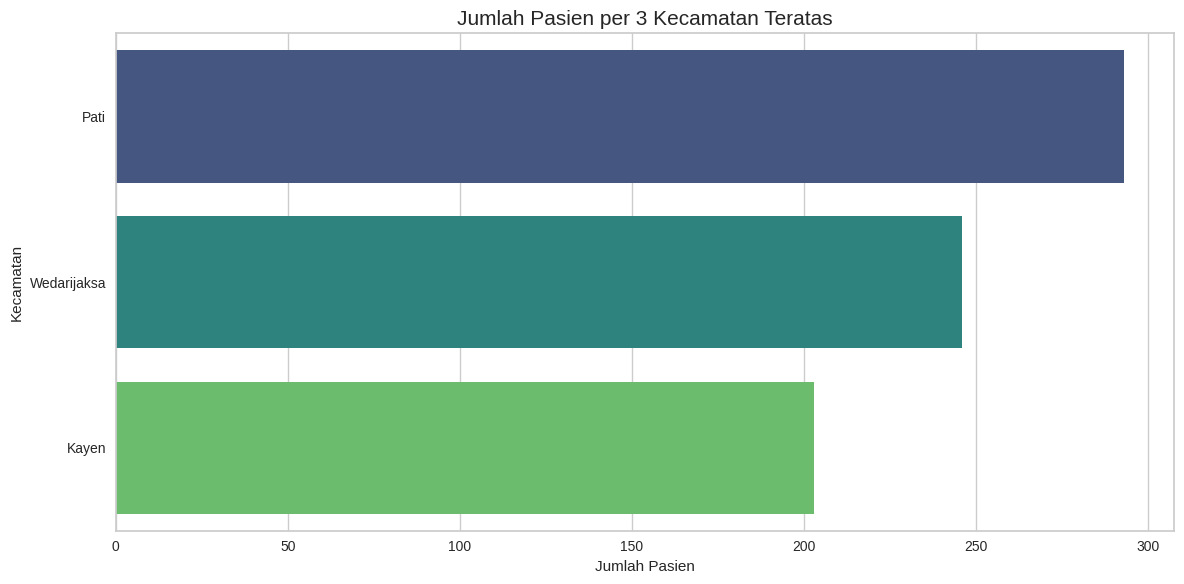

/tmp/ipython-input-5-1906638888.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kdkecamatan', y='UMUR', data=data_for_top_kec_viz, order=top_kecamatans, palette='coolwarm')


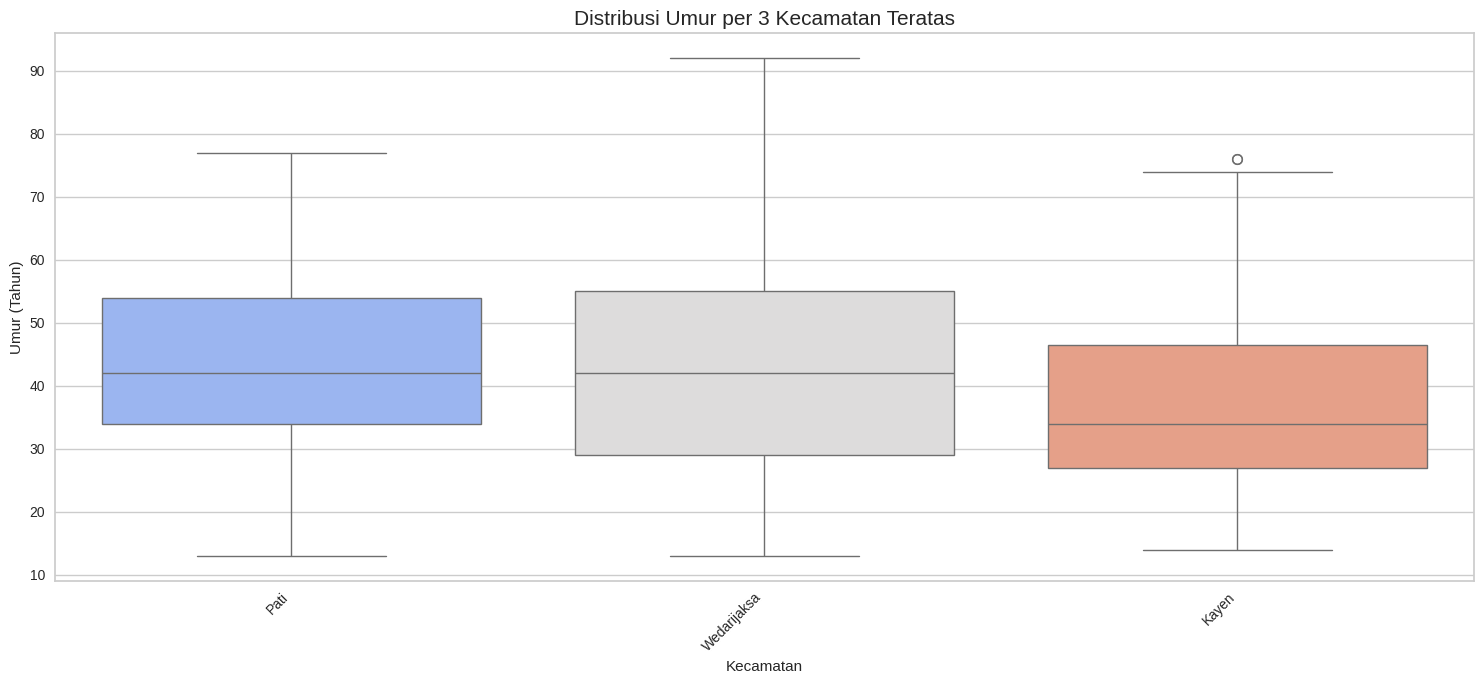


Hasil analisis deskriptif per kecamatan disimpan di: /content/drive/MyDrive/Colab Notebooks/HasilAnalisisRevisiFinal/HasilDeskriptif_PerKecamatan/analisis_3_kecamatan_teratas.json


In [ ]:
# --- LANGKAH 2B: ANALISIS DESKRIPTIF PER KECAMATAN TERATAS ---
print(f"\n\n{'='*60}")
print("LANGKAH 2B: ANALISIS DESKRIPTIF PER KECAMATAN TERATAS")
print(f"{'='*60}")

N_KECAMATAN_TO_ANALYZE = 3
output_dir_desc = os.path.join(output_dir, 'HasilDeskriptif_PerKecamatan')
create_dir_if_not_exists(output_dir_desc)

if 'kdkecamatan' in data_clean.columns:
    top_kecamatans = data_clean['kdkecamatan'].value_counts().nlargest(N_KECAMATAN_TO_ANALYZE).index.tolist()

    print(f"Menganalisis {len(top_kecamatans)} kecamatan dengan jumlah pasien terbanyak.")

    kecamatan_analysis_results = {}
    for i, nama_kecamatan in enumerate(top_kecamatans):
        print(f"\\nKarakteristik untuk Kecamatan (Peringkat {i+1}): {nama_kecamatan}")
        data_kecamatan = data_clean[data_clean['kdkecamatan'] == nama_kecamatan]

        analysis = {'nama_kecamatan': nama_kecamatan, 'jumlah_anggota': len(data_kecamatan)}

        umur_mode = data_kecamatan['UMUR'].mode()
        analysis['umur_dominan'] = int(umur_mode[0]) if not umur_mode.empty else 'N/A'
        analysis['rentang_umur'] = f"{int(data_kecamatan['UMUR'].min())} - {int(data_kecamatan['UMUR'].max())}"

        for col_name in ['jeniskelamin', 'diagnosa', 'kdcarabayar']:
            mode_val = data_kecamatan[col_name].mode()
            analysis[f'{col_name}_dominan'] = mode_val[0] if not mode_val.empty else 'N/A'

        kecamatan_analysis_results[f'Kecamatan_{nama_kecamatan.replace(" ", "_")}'] = analysis

        print(f"  - Jumlah Pasien: {analysis['jumlah_anggota']}")
        print(f"  - Umur Dominan: {analysis['umur_dominan']} tahun (Rentang: {analysis['rentang_umur']})")
        print(f"  - Jenis Kelamin Dominan: {analysis['jeniskelamin_dominan']}")
        print(f"  - Diagnosa Dominan: {analysis['diagnosa_dominan']}")
        print(f"  - Cara Bayar Dominan: {analysis['kdcarabayar_dominan']}")

    # Visualisasi
    data_for_top_kec_viz = data_clean[data_clean['kdkecamatan'].isin(top_kecamatans)]

    plt.figure(figsize=(12, 6))
    sns.countplot(y='kdkecamatan', data=data_for_top_kec_viz, order=top_kecamatans, palette='viridis')
    plt.title(f'Jumlah Pasien per {N_KECAMATAN_TO_ANALYZE} Kecamatan Teratas', fontsize=15)
    plt.xlabel('Jumlah Pasien'); plt.ylabel('Kecamatan'); plt.tight_layout()
    plt.savefig(os.path.join(output_dir_desc, 'jumlah_pasien_per_kecamatan.png')); plt.show()

    plt.figure(figsize=(15, 7))
    sns.boxplot(x='kdkecamatan', y='UMUR', data=data_for_top_kec_viz, order=top_kecamatans, palette='coolwarm')
    plt.title(f'Distribusi Umur per {N_KECAMATAN_TO_ANALYZE} Kecamatan Teratas', fontsize=15)
    plt.xlabel('Kecamatan'); plt.ylabel('Umur (Tahun)'); plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig(os.path.join(output_dir_desc, 'distribusi_umur_per_kecamatan.png')); plt.show()

    analysis_output_path = os.path.join(output_dir_desc, f'analisis_{N_KECAMATAN_TO_ANALYZE}_kecamatan_teratas.json')
    with open(analysis_output_path, 'w', encoding='utf-8') as f:
        json.dump(kecamatan_analysis_results, f, indent=4, ensure_ascii=False)
    print(f"\nHasil analisis deskriptif per kecamatan disimpan di: {analysis_output_path}")

else:
    print("ERROR: Kolom 'kdkecamatan' tidak ditemukan. Analisis deskriptif per kecamatan dilewati.")



LANGKAH 3: K-MEANS CLUSTERING PADA SELURUH DATA BERSIH

Data setelah encoding untuk K-Means (5 baris pertama):
    UMUR  jeniskelamin  diagnosa  kdcarabayar  kdkecamatan
0  54.0             1        57            1            2
1  34.0             0        57            1            3
2  61.0             1        16            3           41
3  35.0             0        57            0           42
4  70.0             0        80            1            5

Menjalankan Elbow Method dengan KElbowVisualizer...


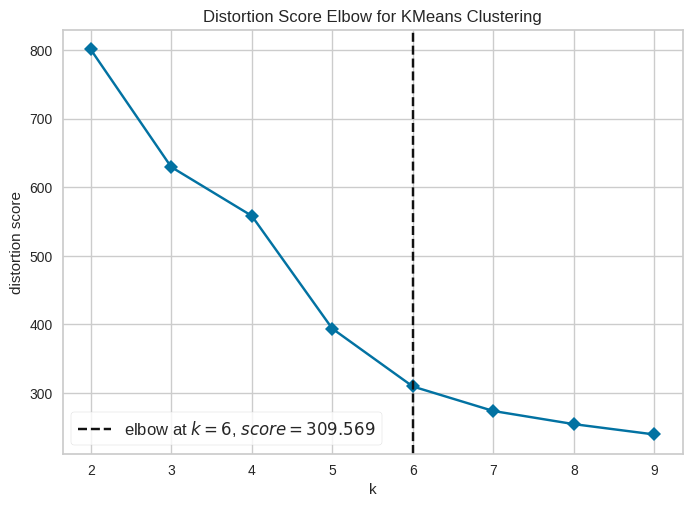


K optimal yang terdeteksi secara otomatis adalah: 6

Menjalankan K-Means dengan K = 6...

--- Evaluasi Kualitas Cluster ---
  - Silhouette Score: 0.499 (Mendekati 1 lebih baik)
  - Davies-Bouldin Index: 0.845 (Mendekati 0 lebih baik)

--- Analisis Karakteristik untuk 6 Cluster ---

Karakteristik Cluster 0:
  - Jumlah Anggota: 857
  - Umur: Rata-rata 43.4 tahun (Dominan: 41, Rentang: 13 - 80)
  - Jenis Kelamin Dominan: P
  - Diagnosa Dominan: PARANOID
  - Cara Bayar Dominan: BPJS Non PBI
  - Kecamatan Dominan: Wedarijaksa

Karakteristik Cluster 1:
  - Jumlah Anggota: 460
  - Umur: Rata-rata 35.9 tahun (Dominan: 28, Rentang: 12 - 81)
  - Jenis Kelamin Dominan: L
  - Diagnosa Dominan: PARANOID
  - Cara Bayar Dominan: BPJS Non PBI
  - Kecamatan Dominan: Kayen

Karakteristik Cluster 2:
  - Jumlah Anggota: 759
  - Umur: Rata-rata 37.1 tahun (Dominan: 24, Rentang: 8 - 77)
  - Jenis Kelamin Dominan: L
  - Diagnosa Dominan: PARANOID
  - Cara Bayar Dominan: BPJS Non PBI
  - Kecamatan Dominan: P

In [ ]:
# --- LANGKAH 3: K-MEANS CLUSTERING PADA DATA KESELURUHAN ---
print(f"\n\n{'='*60}")
print("LANGKAH 3: K-MEANS CLUSTERING PADA SELURUH DATA BERSIH")
print(f"{'='*60}")

kmeans_output_dir = os.path.join(output_dir, 'HasilKMeans_DataUtama')
create_dir_if_not_exists(kmeans_output_dir)

if len(data_clean) < 10:
    print("Jumlah data setelah cleaning terlalu sedikit untuk K-Means. Proses dibatalkan.")
else:
    # 1. REVISI: Menambahkan 'kdkecamatan' sebagai fitur clustering
    features_to_cluster = ['UMUR', 'jeniskelamin', 'diagnosa', 'kdcarabayar', 'kdkecamatan']
    data_for_kmeans = data_clean[features_to_cluster].copy()

    # 2. REVISI: Menambahkan 'kdkecamatan' ke daftar kolom yang akan di-encode
    categorical_cols = ['jeniskelamin', 'diagnosa', 'kdcarabayar', 'kdkecamatan']
    for col in categorical_cols:
        data_for_kmeans[col] = data_for_kmeans[col].astype(str)
        le = LabelEncoder()
        data_for_kmeans[col] = le.fit_transform(data_for_kmeans[col])
    print("\nData setelah encoding untuk K-Means (5 baris pertama):\n", data_for_kmeans.head())

    # 3. Scaling fitur
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(data_for_kmeans)

    # 4. Menentukan K optimal dengan KElbowVisualizer
    print("\nMenjalankan Elbow Method dengan KElbowVisualizer...")
    model = KMeans(random_state=42, n_init='auto')
    max_k = min(10, len(data_clean) - 1)
    visualizer = KElbowVisualizer(model, k=(2, max_k), timings=False)
    visualizer.fit(scaled_features)
    visualizer.show()

    # 5. Menggunakan nilai K dari hasil visualizer secara otomatis
    optimal_k = visualizer.elbow_value_
    if not optimal_k:
        optimal_k = 4 # Nilai default jika elbow tidak terdeteksi
        print(f"Elbow point tidak terdeteksi otomatis, menggunakan K default = {optimal_k}")
    else:
        print(f"\nK optimal yang terdeteksi secara otomatis adalah: {optimal_k}")

    # 6. Menjalankan K-Means dengan K optimal
    print(f"\nMenjalankan K-Means dengan K = {optimal_k}...")
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_features)
    data_clean['cluster'] = cluster_labels

    # 7. Evaluasi Internal
    silhouette_avg = silhouette_score(scaled_features, cluster_labels)
    db_index = davies_bouldin_score(scaled_features, cluster_labels)
    print(f"\n--- Evaluasi Kualitas Cluster ---")
    print(f"  - Silhouette Score: {silhouette_avg:.3f} (Mendekati 1 lebih baik)")
    print(f"  - Davies-Bouldin Index: {db_index:.3f} (Mendekati 0 lebih baik)")

    # 8. Analisis Karakteristik Cluster
    cluster_analysis_results = {}
    print(f"\n--- Analisis Karakteristik untuk {optimal_k} Cluster ---")
    for cluster_num in range(optimal_k):
        data_cluster = data_clean[data_clean['cluster'] == cluster_num]
        analysis = {'cluster_id': cluster_num, 'jumlah_anggota': len(data_cluster)}

        analysis['umur_rata_rata'] = round(data_cluster['UMUR'].mean(), 1)
        analysis['umur_dominan'] = int(data_cluster['UMUR'].mode()[0])
        analysis['rentang_umur'] = f"{int(data_cluster['UMUR'].min())} - {int(data_cluster['UMUR'].max())}"
        for col_analyze in ['jeniskelamin', 'diagnosa', 'kdcarabayar', 'kdkecamatan']:
            analysis[f'{col_analyze}_dominan'] = data_cluster[col_analyze].mode()[0]
        cluster_analysis_results[f'Cluster_{cluster_num}'] = analysis

        print(f"\nKarakteristik Cluster {cluster_num}:")
        print(f"  - Jumlah Anggota: {analysis['jumlah_anggota']}")
        print(f"  - Umur: Rata-rata {analysis['umur_rata_rata']} tahun (Dominan: {analysis['umur_dominan']}, Rentang: {analysis['rentang_umur']})")
        print(f"  - Jenis Kelamin Dominan: {analysis.get('jeniskelamin_dominan','N/A')}")
        print(f"  - Diagnosa Dominan: {analysis.get('diagnosa_dominan','N/A')}")
        print(f"  - Cara Bayar Dominan: {analysis.get('kdcarabayar_dominan','N/A')}")
        print(f"  - Kecamatan Dominan: {analysis.get('kdkecamatan_dominan','N/A')}")


--- Visualisasi Hasil K-Means Clustering ---


/tmp/ipython-input-7-3624363500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='UMUR', data=data_clean, palette='viridis')


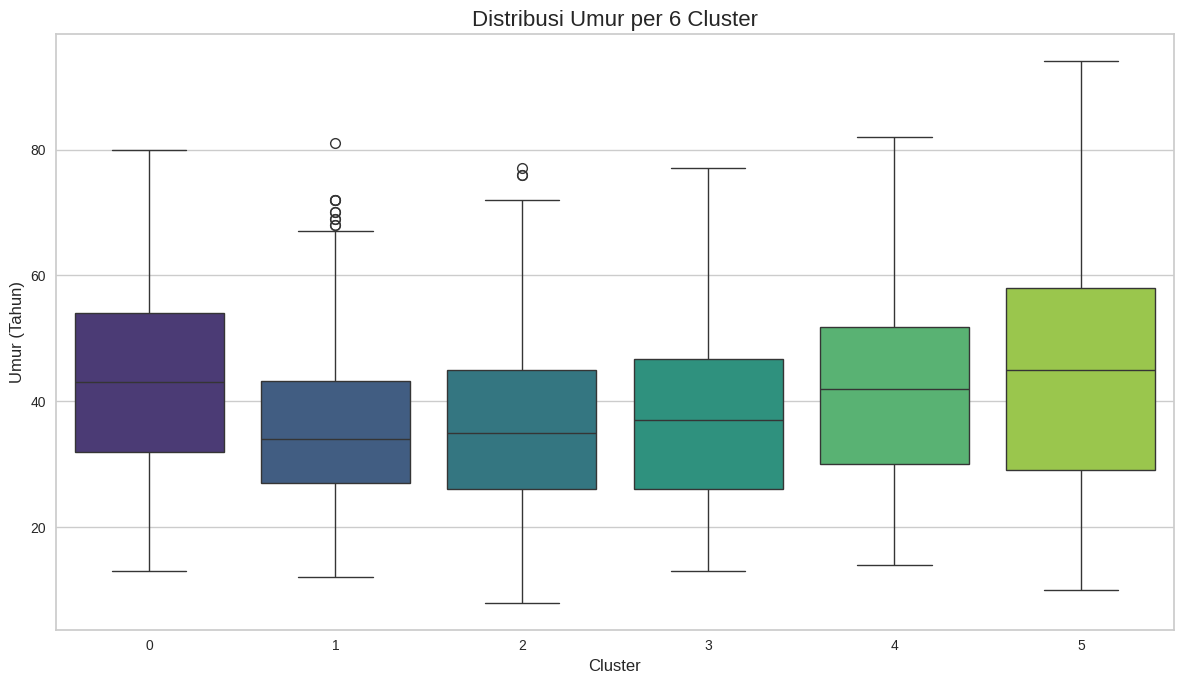

/tmp/ipython-input-7-3624363500.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
/tmp/ipython-input-7-3624363500.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
/tmp/ipython-input-7-3624363500.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
/tmp/ipython-input-7-3624363500.py:28: FutureWarning: 

Pa

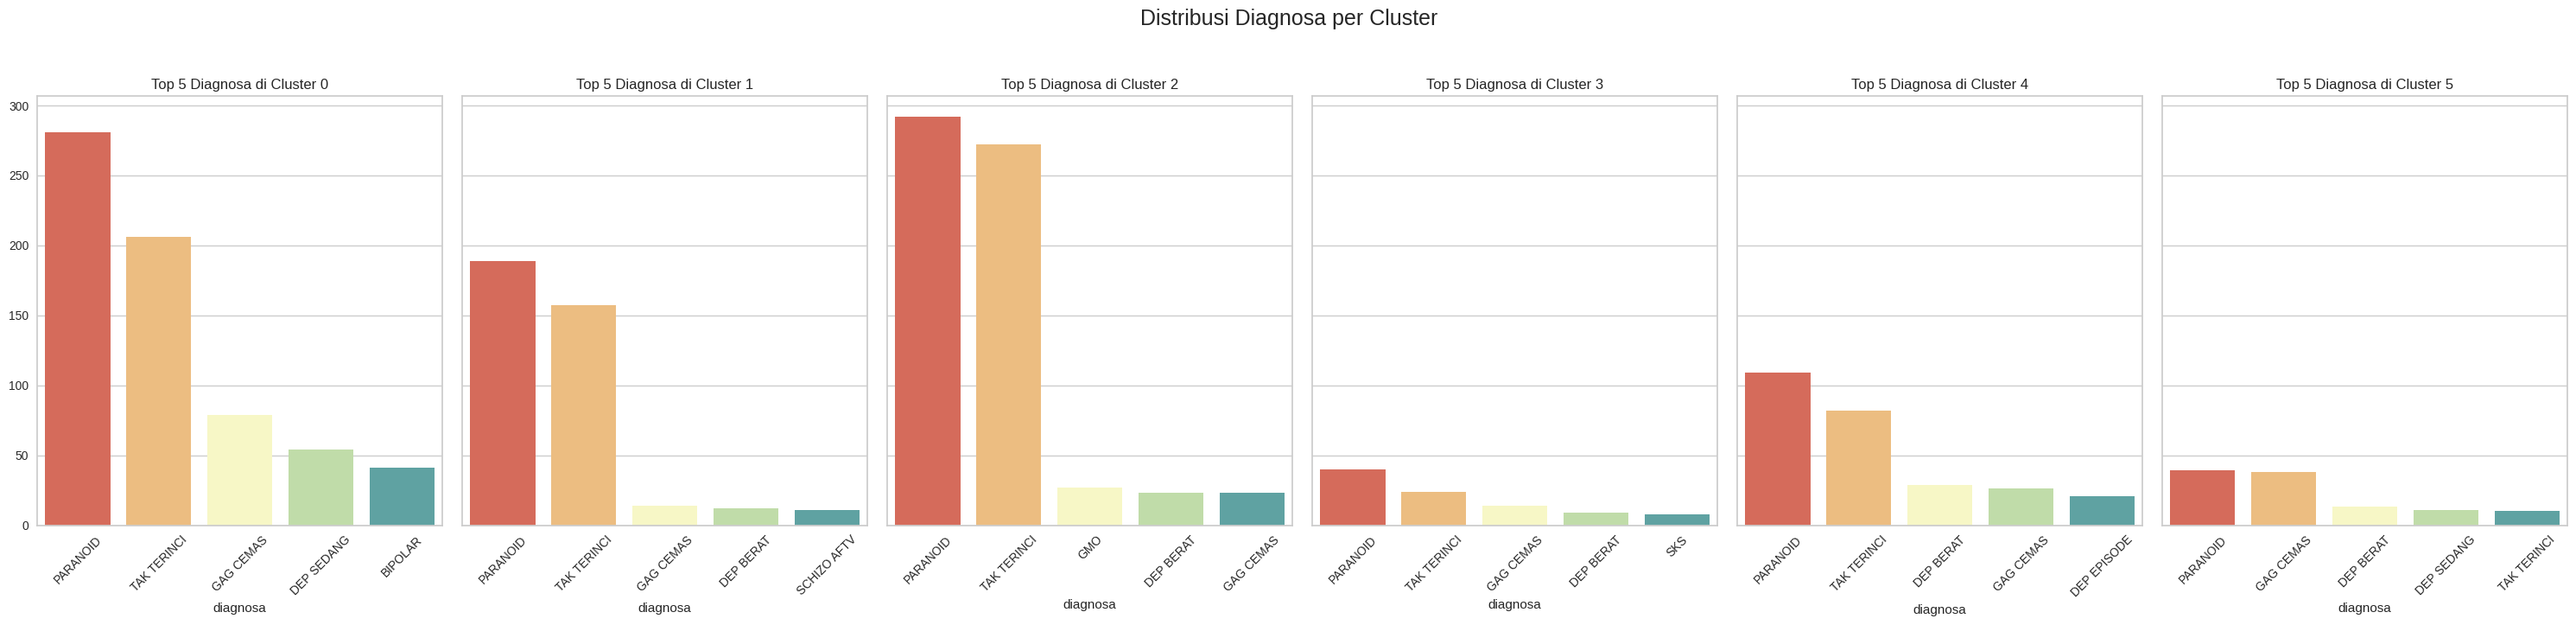

In [ ]:
# --- Visualisasi Hasil K-Means Clustering ---
print("\n--- Visualisasi Hasil K-Means Clustering ---")

# Visualisasi Boxplot untuk Umur
plt.figure(figsize=(12, 7))
sns.boxplot(x='cluster', y='UMUR', data=data_clean, palette='viridis')
plt.title(f'Distribusi Umur per {optimal_k} Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Umur (Tahun)', fontsize=12)
plt.tight_layout()
# Opsional: menyimpan gambar
# plt.savefig(os.path.join(kmeans_output_dir, 'distribusi_umur_per_cluster.png'))
plt.show()


# Visualisasi Barplot untuk Diagnosa
fig, axes = plt.subplots(1, optimal_k, figsize=(optimal_k * 5, 7), sharey=True)
if optimal_k == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for cluster_idx in range(optimal_k):
    ax = axes[cluster_idx]
    data_c = data_clean[data_clean['cluster'] == cluster_idx]
    diagnosa_counts = data_c['diagnosa'].value_counts().nlargest(5)

    sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')

    ax.set_title(f"Top 5 Diagnosa di Cluster {cluster_idx}")

    # REVISI: Menghapus parameter 'ha' yang tidak valid dari ax.tick_params
    # Matplotlib akan menangani alignment secara otomatis dengan baik saat rotasi.
    ax.tick_params(axis='x', rotation=45, labelsize=10)

fig.suptitle('Distribusi Diagnosa per Cluster', fontsize=18, y=1.03)
plt.tight_layout()
# Opsional: menyimpan gambar
# plt.savefig(os.path.join(kmeans_output_dir, 'distribusi_diagnosa_per_cluster.png'))
plt.show()



LANGKAH 4: ANALISIS HUBUNGAN ANTARA CLUSTER DENGAN TUJUAN RUJUKAN

Distribusi Tujuan Rujukan di Setiap Cluster (Jumlah Pasien):
kdtujuanrujuk  Ke Rumah Sakit Lain  Ke Rumah Sakit Lain (Keatas)  Pulang  \
cluster                                                                    
0                                2                             0     827   
1                                1                             1     449   
2                                1                             0     728   
3                                0                             0     125   
4                                0                             0     360   
5                                0                             0     148   

kdtujuanrujuk  Rujuk Balik  Rujuk Ke Poly Lain  Rujuk Rawat Inap  
cluster                                                           
0                       17                  11                 0  
1                        5                   4              

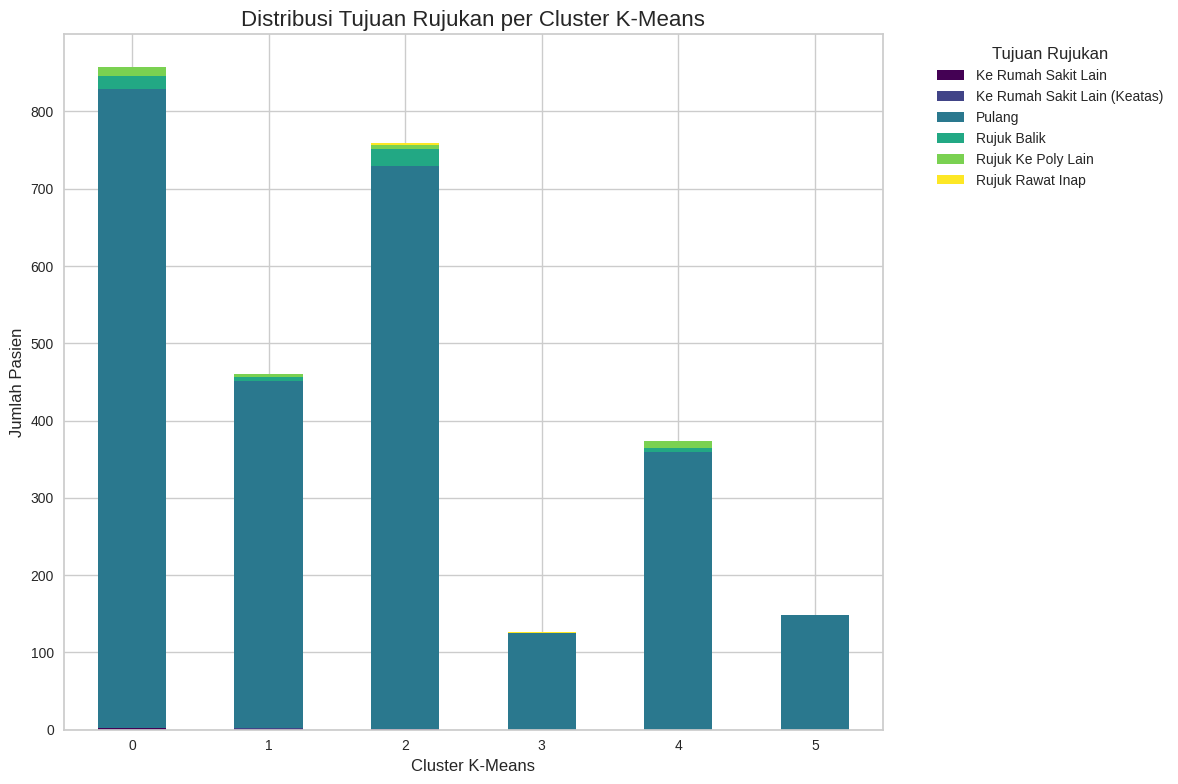

In [ ]:
# --- LANGKAH 4: ANALISIS POST-HOC (HUBUNGAN CLUSTER DENGAN TUJUAN RUJUKAN) ---
print(f"\n\n{'='*60}")
print("LANGKAH 4: ANALISIS HUBUNGAN ANTARA CLUSTER DENGAN TUJUAN RUJUKAN")
print(f"{'='*60}")

if 'cluster' in data_clean.columns and 'kdtujuanrujuk' in data_clean.columns:
    # REVISI: Hanya membuat dan menampilkan tabel silang (crosstab) untuk jumlah absolut
    crosstab_rujukan = pd.crosstab(data_clean['cluster'], data_clean['kdtujuanrujuk'])

    print("\nDistribusi Tujuan Rujukan di Setiap Cluster (Jumlah Pasien):")
    print(crosstab_rujukan)

    # Visualisasi
    crosstab_rujukan.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')
    plt.title('Distribusi Tujuan Rujukan per Cluster K-Means', fontsize=16)
    plt.xlabel('Cluster K-Means', fontsize=12)
    plt.ylabel('Jumlah Pasien', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Tujuan Rujukan', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # Opsional: menyimpan gambar
    # plt.savefig(os.path.join(kmeans_output_dir, 'distribusi_rujukan_per_cluster.png'))
    plt.show()

else:
    print("Kolom 'cluster' atau 'kdtujuanrujuk' tidak ditemukan untuk analisis post-hoc.")


--- Visualisasi Tambahan Hasil K-Means Clustering ---


/tmp/ipython-input-10-170581934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='UMUR', data=data_clean, palette='viridis')


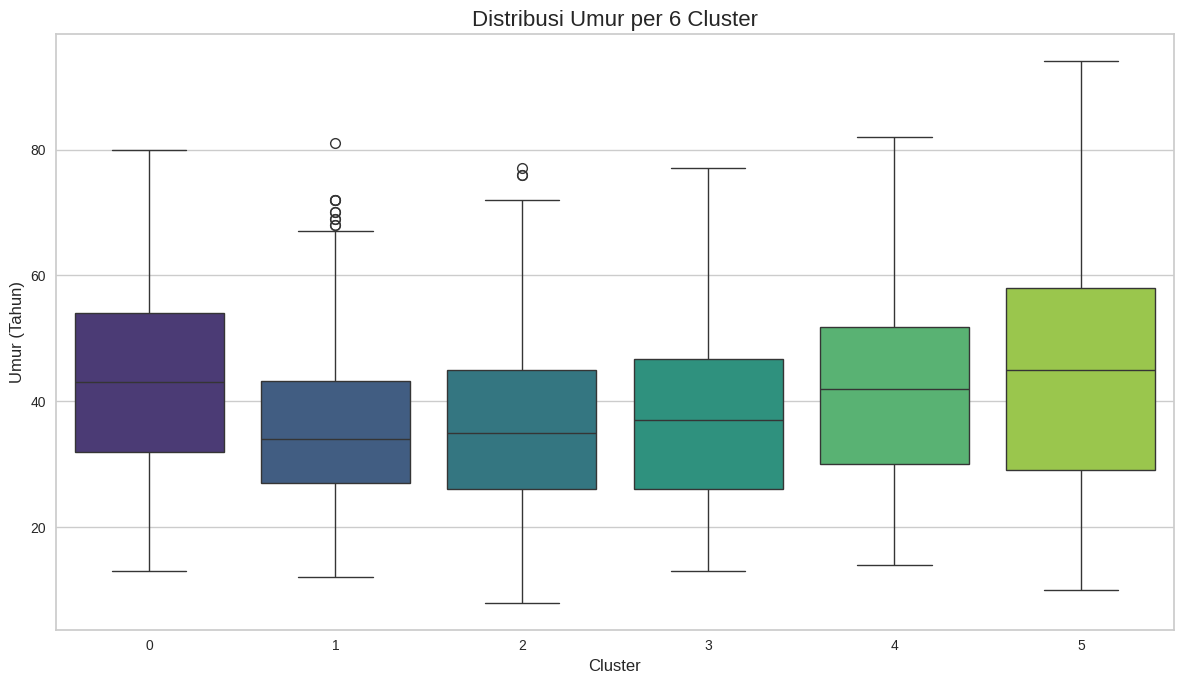

/tmp/ipython-input-10-170581934.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
/tmp/ipython-input-10-170581934.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
/tmp/ipython-input-10-170581934.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
/tmp/ipython-input-10-170581934.py:30: FutureWarning: 

Pa

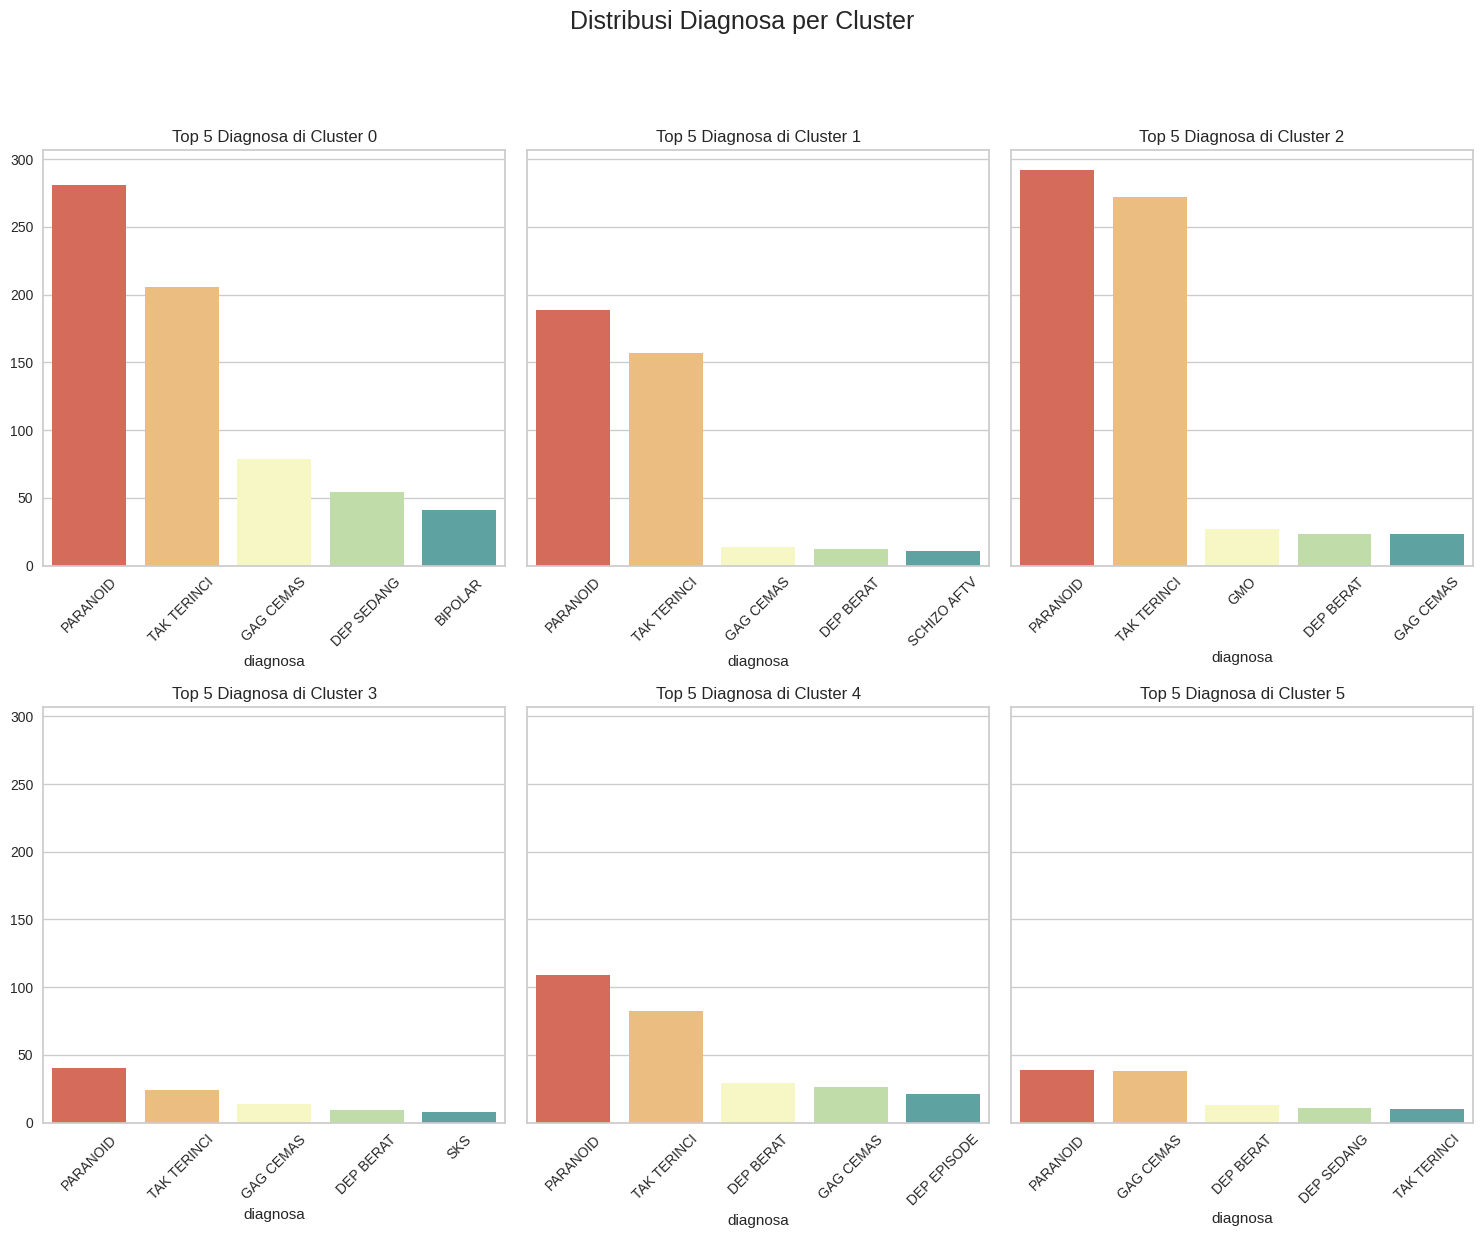

In [ ]:
# --- Visualisasi Tambahan Hasil K-Means Clustering ---
print("\n--- Visualisasi Tambahan Hasil K-Means Clustering ---")

# Visualisasi Boxplot untuk Umur
plt.figure(figsize=(12, 7))
sns.boxplot(x='cluster', y='UMUR', data=data_clean, palette='viridis')
plt.title(f'Distribusi Umur per {optimal_k} Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Umur (Tahun)', fontsize=12)
plt.tight_layout()
# Opsional: menyimpan gambar
# plt.savefig(os.path.join(kmeans_output_dir, 'distribusi_umur_per_cluster.png'))
plt.show()


# Visualisasi Barplot untuk Diagnosa
# Menentukan jumlah baris dan kolom untuk subplot berdasarkan jumlah cluster
n_clusters = data_clean['cluster'].nunique()
n_cols = 3  # Tampilkan 3 grafik per baris
n_rows = (n_clusters + n_cols - 1) // n_cols  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 6), sharey=True)
axes = axes.flatten() # Membuat array 1D agar mudah di-loop

for cluster_idx in range(n_clusters):
    ax = axes[cluster_idx]
    data_c = data_clean[data_clean['cluster'] == cluster_idx]
    diagnosa_counts = data_c['diagnosa'].value_counts().nlargest(5) # Ambil 5 teratas

    sns.barplot(x=diagnosa_counts.index, y=diagnosa_counts.values, ax=ax, palette='Spectral')
    ax.set_title(f"Top 5 Diagnosa di Cluster {cluster_idx}")
    ax.tick_params(axis='x', rotation=45, labelsize=10) # ha='right' untuk alignment

# Menyembunyikan subplot yang tidak terpakai jika ada
for i in range(n_clusters, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Distribusi Diagnosa per Cluster', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout untuk suptitle
# Opsional: menyimpan gambar
# plt.savefig(os.path.join(kmeans_output_dir, 'distribusi_diagnosa_per_cluster.png'))
plt.show()

In [ ]:
# --- Penyimpanan Hasil Akhir ---
clustered_data_path = os.path.join(kmeans_output_dir, 'data_utama_clustered.csv')
data_clean.to_csv(clustered_data_path, index=False)
print(f"\nData utama dengan label cluster disimpan di: '{clustered_data_path}'")

analysis_output_path = os.path.join(kmeans_output_dir, 'analisis_cluster_utama.json')
with open(analysis_output_path, 'w', encoding='utf-8') as f:
    json.dump(cluster_analysis_results, f, indent=4, ensure_ascii=False)
print(f"Hasil analisis karakteristik cluster utama disimpan di: '{analysis_output_path}'")

print("\n--- Analisis Selesai --- ")


Data utama dengan label cluster disimpan di: '/content/drive/MyDrive/Colab Notebooks/HasilAnalisisRevisiFinal/HasilKMeans_DataUtama/data_utama_clustered.csv'
Hasil analisis karakteristik cluster utama disimpan di: '/content/drive/MyDrive/Colab Notebooks/HasilAnalisisRevisiFinal/HasilKMeans_DataUtama/analisis_cluster_utama.json'

--- Analisis Selesai --- 
